# 05 -- Feature Validation
**Purpose:** Verify that every feature in the matrix adds signal, does not leak the label, and is not redundant.

**Input:** `data/processed/feature_matrix.parquet`
**Output:** `data/processed/validated_features.parquet` | `reports/05_feature_validation.txt`

In [2]:
import pandas as pd

# Load the 52 features we built in Stage 6
X = pd.read_parquet(r"../data/processed\feature_matrix.parquet")

# Load the fraud labels (0 = legit, 1 = fraud)
y = pd.read_parquet(r"../data/processed\target.parquet").squeeze()

print(X.shape)
print(y.value_counts())


(50800, 52)
is_fraud
0    50550
1      250
Name: count, dtype: int64


## Learning Objectives
- Detect and remove zero-variance features
- Detect and remove highly correlated features (multicollinearity)
- Run a leakage detection check on every feature
- Understand preliminary feature importance before model training

In [3]:
from scipy.stats import pointbiserialr

# Store results
correlations = {}

# Loop over every feature column
for col in X.columns:
    corr, pvalue = pointbiserialr(X[col], y)
    correlations[col] = {"correlation": round(corr, 4), "pvalue": round(pvalue, 4)}

# Convert to DataFrame and sort by absolute correlation (strongest first)
corr_df = pd.DataFrame(correlations).T
corr_df["abs_corr"] = corr_df["correlation"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=False)

print(corr_df.head(15))


                            correlation  pvalue  abs_corr
is_round_number                  0.4595     0.0    0.4595
is_new_country                   0.4327     0.0    0.4327
has_supporting_doc              -0.1434     0.0    0.1434
invoice_match_flag              -0.1325     0.0    0.1325
is_new_beneficiary               0.1208     0.0    0.1208
amount_zscore_30d                0.1180     0.0    0.1180
amount_zscore_90d                0.1158     0.0    0.1158
is_primary_account              -0.0902     0.0    0.0902
counterparty_sanction_flag       0.0892     0.0    0.0892
log_amount_usd                   0.0650     0.0    0.0650
turnover_to_txn_ratio            0.0605     0.0    0.0605
retry_count                      0.0484     0.0    0.0484
submission_hour                 -0.0342     0.0    0.0342
firc_generated                  -0.0286     0.0    0.0286
corridor_fatf_score              0.0267     0.0    0.0267


## Business Context
A feature matrix with 37 features sounds impressive.
A feature matrix where 5 are redundant, 2 have near-zero variance, and 1 leaks the label is a liability.
This notebook is your quality gate before model training.

## Step 1 -- Variance Check
For every numeric feature, compute variance.
Flag any feature with variance < 0.01. State whether to drop or keep each one and why.

## Step 2 -- Correlation Matrix
Compute Pearson correlation for all numeric features. Plot a heatmap.
For any pair with |correlation| > 0.85: decide which to drop and why.

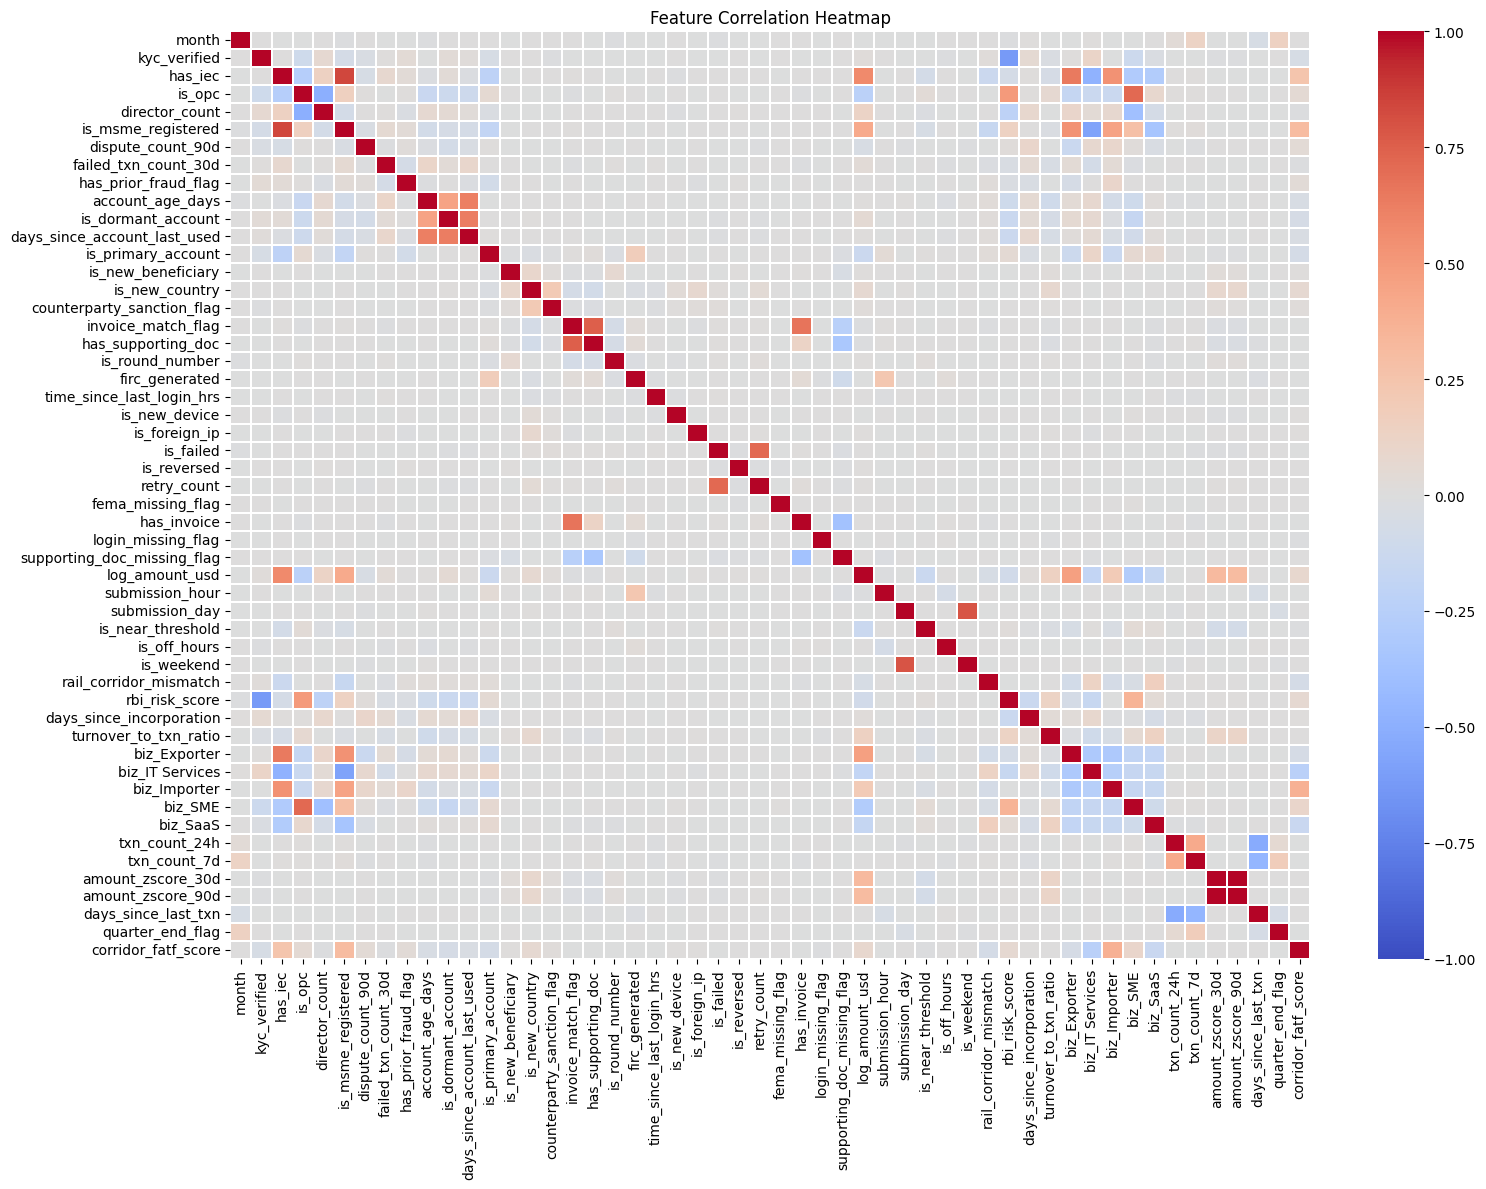

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation between features (not with label — between features themselves)
corr_matrix = X.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [5]:
# Drop redundant features identified in heatmap review
cols_to_drop = [
    "amount_zscore_30d",
    "is_dormant_account", 
    "account_age_days"
]

X_clean = X.drop(columns=cols_to_drop)

print(f"Features before: {X.shape[1]}")
print(f"Features after:  {X_clean.shape[1]}")


Features before: 52
Features after:  49


In [6]:
X_clean.to_parquet(r"../data/processed\feature_matrix_clean.parquet", index=False)
print("Saved: feature_matrix_clean.parquet")
print(f"Shape: {X_clean.shape}")


Saved: feature_matrix_clean.parquet
Shape: (50800, 49)


## Step 3 -- Leakage Detection
For each feature, train a single-feature Logistic Regression and compute AUC-ROC.
Any feature with single-feature AUC > 0.85 is suspicious -- may be encoding the label directly.
List all suspicious features. Investigate each one before dropping.

## Step 4 -- Preliminary Feature Importance
Train a Decision Tree (max_depth=3 only) on the full feature matrix.
Plot feature importances. Top 5: do they match your domain intuition from Notebook 04 Step 1?

## Step 5 -- Final Feature List
After removing zero-variance, highly correlated, and leaked features:
print the final list. State the final feature count. Save to data/processed/validated_features.parquet.

## Definition of Done
- [ ] Variance check complete -- all near-zero features documented and decided
- [ ] Correlation matrix built -- all high-correlation pairs resolved
- [ ] Leakage detection run on every feature
- [ ] Preliminary importance plot produced
- [ ] Final validated feature list saved
- [ ] You can explain why each remaining feature is in the matrix

In [7]:
temporal_leakage_cols = ["is_reversed", "is_failed", "firc_generated"]

X_clean = X_clean.drop(columns=temporal_leakage_cols)

print(f"Features after leakage drop: {X_clean.shape[1]}")


Features after leakage drop: 46


In [8]:
X_clean.to_parquet(r"../data/processed\feature_matrix_clean.parquet", index=False)
print("Saved: feature_matrix_clean.parquet")
print(f"Final shape: {X_clean.shape}")


Saved: feature_matrix_clean.parquet
Final shape: (50800, 46)
